# **Análisis Exploratorio de Datos - Viviendas en Arriendo**



# **Librerías**

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.model_selection import train_test_split
from pathlib import Path
import plotly.express as px
import squarify

# **Cargar el Dat Set**

In [32]:

# NO MODIFICAR LAS SIGUIENTES 2 LÍNEAS, YA QUE MUESTRAN MEJOR EL DATAFRAME AL HACER "PRINT" O "HEAD"
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.options.display.float_format = '{:,.0f}'.format

In [33]:
from pathlib import Path
import pandas as pd

ruta = Path.cwd().parent / "data" / "05.02.2026 EXTRACCION VIVIENDA FR.xlsx"

df = pd.read_excel(ruta)

X = df.drop(columns=["Precio"])
y = df["Precio"]


In [34]:
df = pd.concat([X, y], axis=1)

display(df.head())

,ID,Barrio,Tipo de Inmueble,Estado,Antigüedad,Área Construida (m2),Área Privada (m2),Estrato,Baños,Habitaciones,Parqueaderos,Piso N°,URL,Precio
0,193673918,Boston,Apartamento,Usado,NaN,60,60,4,2,3,0,4,https://wwwfincaraizcomco/apartamento-en-arrie...,1700000
1,193622107,Manrique,Casa,Usado,16 a 30 años,130,130,2,2,3,0,3,https://wwwfincaraizcomco/casa-en-arriendo-en-...,2200000
2,193621915,Robledo,Apartamento,Usado,más de 30 años,52,52,3,1,3,0,12,https://wwwfincaraizcomco/apartamento-en-arrie...,1400000
3,193550885,El Poblado,Apartamento,Usado,9 a 15 años,95,95,6,2,3,2,10,https://wwwfincaraizcomco/apartamento-en-arrie...,5100000
4,193459016,La salle,Apartamento,Usado,16 a 30 años,114,114,5,2,3,1,NaN,https://wwwfincaraizcomco/apartamento-en-arrie...,4200000


## Limpieza de datos

In [35]:
import unicodedata

def limpiar_texto(texto):
    if pd.isna(texto):
        return texto
    
    # quitar tildes
    texto = ''.join(
        c for c in unicodedata.normalize('NFKD', str(texto))
        if not unicodedata.combining(c)
    )
    
    return (
        texto
        .strip()
        .upper()
        .replace('\n', ' ')
    )

df['Barrio_clean'] = df['Barrio'].apply(limpiar_texto)
df['Barrio_clean'] = df['Barrio_clean'].str.replace(r'\s+', ' ', regex=True)

In [36]:
df.groupby('Barrio_clean').size().sort_values(ascending=False)

Barrio_clean
EL POBLADO        967
LAURELES          613
BELEN             291
CALASANZ          257
LAS PALMAS        166
                 ... 
LAS ESMERALDAS      1
LAS BRUJAS          1
LA TABLAZA          1
LA MAGNOLIA         1
ZUNIGA              1
Length: 231, dtype: int64

C:\Users\Zenbook\AppData\Local\Temp\ipykernel_10036\789828167.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='viridis', edgecolor='black')


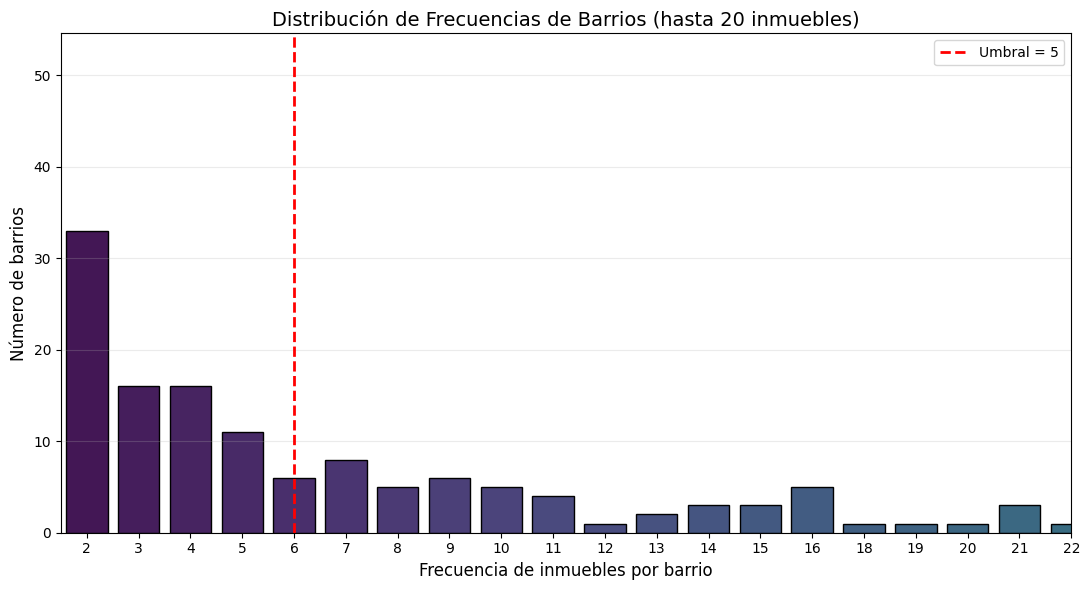

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

frecuencia = df['Barrio_clean'].value_counts()

# Contar cuántos barrios tienen cada frecuencia
counts = frecuencia.value_counts().sort_index()

plt.figure(figsize=(11, 6))
sns.barplot(x=counts.index, y=counts.values, palette='viridis', edgecolor='black')
plt.axvline(x=5, color='red', linestyle='--', linewidth=2, label='Umbral = 5')

plt.xlim(0.5, 20)
plt.xlabel('Frecuencia de inmuebles por barrio', fontsize=12)
plt.ylabel('Número de barrios', fontsize=12)
plt.title('Distribución de Frecuencias de Barrios (hasta 20 inmuebles)', fontsize=14)
plt.xticks(range(1, 21))
plt.legend()
plt.grid(alpha=0.25, axis='y')
plt.tight_layout()
plt.show()

C:\Users\Zenbook\AppData\Local\Temp\ipykernel_10036\2289020860.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


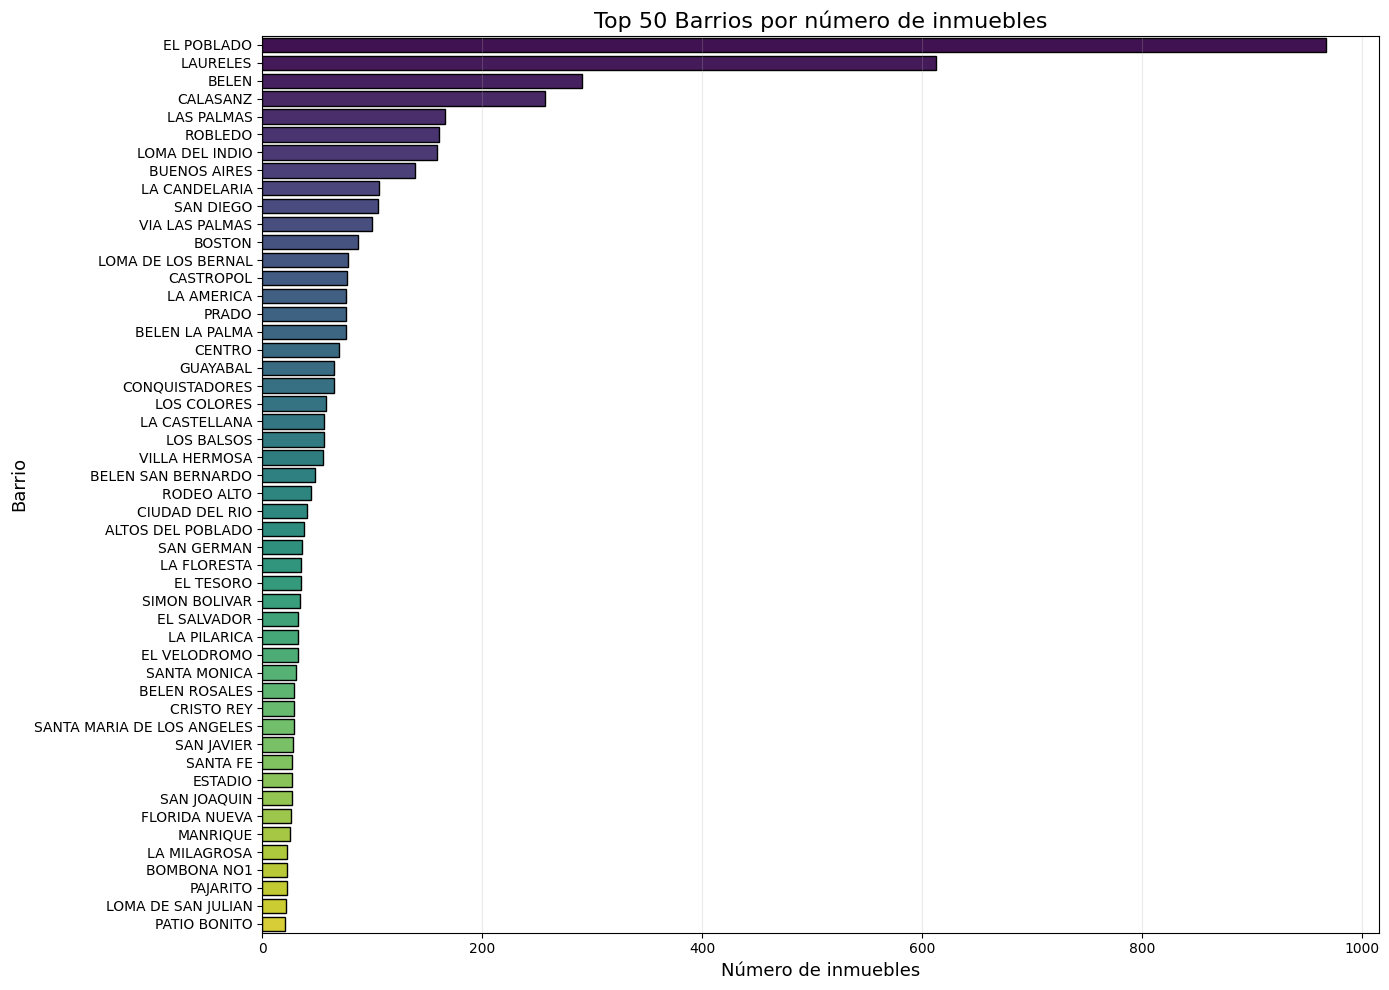

In [38]:
top_barrios = df['Barrio_clean'].value_counts().head(50)

plt.figure(figsize=(14, 10))
sns.barplot(
    x=top_barrios.values,
    y=top_barrios.index,
    palette='viridis',
    edgecolor='black'
)

plt.title('Top 50 Barrios por número de inmuebles', fontsize=16)
plt.xlabel('Número de inmuebles', fontsize=13)
plt.ylabel('Barrio', fontsize=13)
plt.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

In [39]:
frecuencia = df['Barrio_clean'].value_counts()

barrios_validos = frecuencia[frecuencia >= 5].index

df['Barrio_group'] = df['Barrio_clean'].apply(
    lambda x: x if x in barrios_validos else 'OTROS'
)



In [40]:
df.groupby('Barrio_group').size().sort_values(ascending=False)

Barrio_group
EL POBLADO              967
LAURELES                613
BELEN                   291
CALASANZ                257
OTROS                   230
                       ... 
SAN ANTONIO DE PRADO      5
ALFONSO LOPEZ             5
LAS GRANJAS               5
LOS NARANJOS              5
COLON                     5
Length: 115, dtype: int64

# **Checamos la variable Target Y, que en nuestro caso es `Precio`**


In [41]:
df['Precio'].describe()

count         5,628
mean      5,120,721
std      19,181,197
min         450,000
25%       2,350,000
50%       3,500,000
75%       5,000,000
max     750,000,000
Name: Precio, dtype: float64

**Observación**

Vemos que la variable precio tiene un Max de 750 millones (posiblemente en el scraping se nos escaparon propiedades en venta) y un min de 450 mil(posiblemente de una habitación en arriendo)

In [42]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import numpy as np

fig = make_subplots(rows=1, cols=3, subplot_titles=["Distribución de Precio", "Boxplot de Precio", "Distribución de log(Precio)"])

fig.add_trace(go.Histogram(x=df["Precio"], name="Precio", showlegend=False), row=1, col=1)

fig.add_trace(go.Box(x=df["Precio"], name="Precio", showlegend=False), row=1, col=2)

fig.add_trace(go.Histogram(x=np.log1p(df["Precio"]), name="log(Precio)", showlegend=False), row=1, col=3)

fig.update_layout(title="Análisis de Precio", height=400, width=1500)
fig.show()


**Oservación**

La gráfica ya nos cuenta que la distribución inicial de nuestra variable `Precio` si esta muy sesgada a la derecha, y vemos unos cuantos outliers, los cuales podríamos inferir son las propiedades en venta, pero si usamos una distribución logarítmica, podemos observar mejor la distribución.

In [43]:
df_filtrado = df[(df["Precio"] >= 500_000) & (df["Precio"] <= 50_000_000)].copy()


**Observación**

Hacemos filtrado de precio con Minimo 500,000 y 50 millones ya que dentro de la plataforma de Finca Raiz, hay unas cuentas propiedades con este precio de arriendo

In [44]:
print(f"Filas originales: {len(df)}")
print(f"Filas filtradas: {len(df_filtrado)}")
print(f"Filas eliminadas: {len(df) - len(df_filtrado)}")
print(f"Porcentaje eliminado: {((len(df) - len(df_filtrado)) / len(df) * 100):.2f}%")


Filas originales: 5628
Filas filtradas: 5612
Filas eliminadas: 16
Porcentaje eliminado: 0.28%


In [45]:
fig = make_subplots(rows=1, cols=3, subplot_titles=["Distribución de Precio Filtrado", "Boxplot de Precio Filtrado", "Distribución de log(Precio) Filtrado"])

fig.add_trace(go.Histogram(x=df_filtrado["Precio"], name="Precio", showlegend=False), row=1, col=1)

fig.add_trace(go.Box(x=df_filtrado["Precio"], name="Precio", showlegend=False), row=1, col=2)

# A una escala logarítmica, para ver la distribución mas normalizada de los precios
fig.add_trace(go.Histogram(x=np.log1p(df_filtrado["Precio"]), name="log(Precio)", showlegend=False), row=1, col=3)

fig.update_layout(title="Análisis de Precio Filtrado", height=400, width=1000)
fig.show()

**Observación**

Aun después del filtrado de Precio entre 500.000 y 50.000.000, la distribución continúa sesgada a la derecha, con concentración de observaciones en valores bajos y medios, y una cola larga hacia precios altos. El boxplot evidencia la presencia de valores altos atípicos, que no necesariamente corresponden a errores, sino a inmuebles en arriendo de segmentos más costosos dentro de la plataforma. Al aplicar una transformación logarítmica, la distribución se vuelve más simétrica, lo que hace de log(Precio) una alternativa más apropiada para análisis posteriores.

# **Heatmap de Correlaciones!**

In [46]:
df_filtrado.columns

Index(['ID', 'Barrio', 'Tipo de Inmueble', 'Estado', 'Antigüedad',
       'Área Construida (m2)', 'Área Privada (m2)', 'Estrato', 'Baños',
       'Habitaciones', 'Parqueaderos', 'Piso N°', 'URL', 'Precio',
       'Barrio_clean', 'Barrio_group'],
      dtype='object')

In [47]:
cols_numericas = ["Estrato", "Baños", "Habitaciones", "Piso N°", 
                  "Área Construida (m2)", "Área Privada (m2)", 
                  "Parqueaderos", "Precio"]

corr = df_filtrado[cols_numericas].corr().round(2)

fig = px.imshow(corr, 
                text_auto=True, 
                color_continuous_scale="RdBu_r",
                title="Correlación entre variables numéricas",
                width=700, height=600)
fig.show()

**Observación**

1. Notamos una correlación muy alta entre las variables de `Área`, lo que sugiere que ambas contienen casi la misma información. También vemos una relación fuerte entre `Baños` y `Precio` (`0.68`), incluso mayor que la del área. Además, `Baños` y `Habitaciones` también presentan una alta correlación, algo esperable porque, por lo general, a mayor número de habitaciones, mayor número de baños.

2. La relación entre `Estrato` y `Precio` es de `0.47`, lo que indica que esta variable sí influye en el precio. Algo similar ocurre con `Habitaciones` y `Baños`, que también muestran una relación importante con esta variable.

3. Finalmente, observamos que `Piso N°` tiene una correlación baja con `Precio`, por lo que podría considerarse eliminarla más adelante si vemos que no aporta mucho al análisis o al modelo.



# **Limpieza e imputación de datos**

In [48]:
df_filtrado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5612 entries, 0 to 5627
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    5612 non-null   int64  
 1   Barrio                5612 non-null   object 
 2   Tipo de Inmueble      5612 non-null   object 
 3   Estado                5612 non-null   object 
 4   Antigüedad            4218 non-null   object 
 5   Área Construida (m2)  5489 non-null   float64
 6   Área Privada (m2)     5489 non-null   float64
 7   Estrato               5561 non-null   float64
 8   Baños                 5570 non-null   float64
 9   Habitaciones          5521 non-null   float64
 10  Parqueaderos          5612 non-null   int64  
 11  Piso N°               2929 non-null   float64
 12  URL                   5612 non-null   object 
 13  Precio                5612 non-null   int64  
 14  Barrio_clean          5612 non-null   object 
 15  Barrio_group          5612

In [49]:
# Cambiar de tipo de variable de ID a string
df["ID"] = df["ID"].astype(str)

## **Análisis de Valores Nulos**

### **Valores Nulos**

In [50]:
nulos = pd.DataFrame({
    'Nulos': df_filtrado.isnull().sum(),
    '% Nulos': (df_filtrado.isnull().mean() * 100).round(2)
})
nulos[nulos['Nulos'] > 0].sort_values('% Nulos', ascending=False)

,Nulos,% Nulos
Piso N°,2683,48
Antigüedad,1394,25
Área Construida (m2),123,2
Área Privada (m2),123,2
Habitaciones,91,2
Estrato,51,1
Baños,42,1


In [51]:
nulos_filtrado = nulos[nulos['Nulos'] > 0].sort_values('% Nulos', ascending=False)

fig = px.bar(nulos_filtrado, x=nulos_filtrado.index, y='% Nulos',
             text='% Nulos',
             title="Porcentaje de Valores Faltantes por Variable",
             labels={'x': 'Variable', '% Nulos': '% Nulos'},
             width=800, height=400)

fig.update_traces(texttemplate='%{text}%', textposition='outside')
fig.update_layout(
    xaxis_tickangle=-30,
    yaxis_range=[0, nulos_filtrado['% Nulos'].max() * 1.15]
)
fig.show()

**Observación**

Podemos ver que las variables `Piso N°` y `Antigüedad` presentan mas valores faltantes, se podría observar la hipótesis de si esos valores faltantes de la variable `Piso N°` es porque son casas y no apartamentos.

### **Checamos la variable `Piso N°`**

In [52]:
# Analicemos la cantidad de datos faltantes por variable = "Piso N°"

df_filtrado[df_filtrado['Piso N°'].isnull()]['Tipo de Inmueble'].value_counts()

Tipo de Inmueble
Apartamento      2033
Casa              457
Apartaestudio     193
Name: count, dtype: int64

In [53]:
conteo = df_filtrado[df_filtrado['Piso N°'].isnull()]['Tipo de Inmueble'].value_counts()

fig = px.pie(values=conteo.values, names=conteo.index,
             title="Nulos en Piso N° por Tipo de Inmueble",
             width=600, height=400)
fig.show()

**Observación**

La hipótesis queda rechazada puesto que los apartamentos son los valores que presentan el mayor número de valores faltantes, mientras que casa tiene 457, la idea es imputar casa con 1 directamente, ya que son de un solo piso. Los nulos restantes (Apartamentos y Apartaestudios) se tratarán con KNNImputer.

In [54]:
df_filtrado.columns

Index(['ID', 'Barrio', 'Tipo de Inmueble', 'Estado', 'Antigüedad',
       'Área Construida (m2)', 'Área Privada (m2)', 'Estrato', 'Baños',
       'Habitaciones', 'Parqueaderos', 'Piso N°', 'URL', 'Precio',
       'Barrio_clean', 'Barrio_group'],
      dtype='object')

In [55]:
df_casas = df_filtrado[df_filtrado['Tipo de Inmueble'] == 'Casa'].copy()
df_casas['Piso N°'].value_counts(dropna=False)

Piso N°
NaN    457
1      249
2      115
3       24
4        4
7        1
Name: count, dtype: int64

In [56]:
# Analizamos la variable barrio para ver la cantidad de inmuebles para su posible imputación con KNN
df_filtrado.groupby('Barrio_group').size().sort_values(ascending=False)

Barrio_group
EL POBLADO              965
LAURELES                613
BELEN                   290
CALASANZ                257
OTROS                   227
                       ... 
SAN ANTONIO DE PRADO      5
ALFONSO LOPEZ             5
LAS GRANJAS               5
LOS NARANJOS              5
COLON                     5
Length: 115, dtype: int64

In [57]:
#conteo de total de barrios
total_barrios = df['Barrio_group'].nunique()
total_barrios

115

In [58]:
df_filtrado['Piso N°'] = df_filtrado['Piso N°'].replace({7: np.nan})

In [59]:
def piso_cat(x):
    if pd.isna(x):
        return 'missing'
    elif x == 1:
        return '1'
    elif x == 2:
        return '2'
    else:
        return '3+'

df_filtrado['Piso_cat'] = df_filtrado['Piso N°'].apply(piso_cat)

In [60]:
df_filtrado.groupby('Piso_cat').size()

Piso_cat
1           605
2           488
3+         1726
missing    2793
dtype: int64

In [61]:
#Imputamos los datos faltantes de "Piso N°" con el valor 1, ya que es lo más lógico para las casas, ya que no suelen tener más de un piso.
df_filtrado.loc[(df_filtrado['Piso N°'].isnull()) & (df_filtrado['Tipo de Inmueble']== "Casa"), "Piso N°"] = 1

In [62]:
# Verificamos que se haya imputado correctamente
df_filtrado[df_filtrado["Tipo de Inmueble"] == "Casa"]["Piso N°"].isnull().sum()

0

### **Checamos la variable `Antigüedad`**

In [63]:
df_filtrado['Antigüedad'].value_counts()

Antigüedad
1 a 8 años        1300
16 a 30 años      1243
9 a 15 años        742
más de 30 años     521
menor a 1 año      412
Name: count, dtype: int64

In [64]:
conteo = df_filtrado['Antigüedad'].value_counts()

fig = px.bar(x=conteo.index, y=conteo.values,
             text=conteo.values,
             title="Distribución de Antigüedad",
             labels={'x': 'Antigüedad', 'y': 'Cantidad'},
             width=800, height=600)

fig.update_traces(textposition='outside')
fig.update_layout(xaxis_tickangle=-30)
fig.show()

In [65]:
# Cruce con precio para ver si influye
df_filtrado.groupby("Antigüedad")["Precio"].describe()

,count,mean,std,min,25%,50%,75%,max
Antigüedad,,,,,,,,
1 a 8 años,"1,300","4,602,072","4,137,479","550,000","2,500,000","3,600,000","5,300,000","45,000,000"
16 a 30 años,"1,243","4,402,568","4,198,999","550,000","2,350,000","3,400,000","4,725,000","50,000,000"
9 a 15 años,742,"4,645,309","3,681,708","550,000","2,562,500","3,800,000","5,500,000","45,000,000"
menor a 1 año,412,"3,842,633","3,284,419","920,000","2,275,000","3,000,000","4,200,000","38,000,000"
más de 30 años,521,"4,619,825","4,739,287","750,000","2,100,000","3,200,000","5,200,000","45,000,000"


In [66]:
df_filtrado["Precio"].describe()

count        5,612
mean     4,425,405
std      4,077,955
min        500,000
25%      2,350,000
50%      3,500,000
75%      5,000,000
max     50,000,000
Name: Precio, dtype: float64

**Observación**
1. 1 a 8 años: tiene el promedio de precios más alto, con 4,828,463, podemos inferir que los inmuebles más modernos se arriendan a mayor valor.
2. **menor a 1 año** tiene el promedio más bajo ($3,842,633), posiblemente porque son proyectos nuevos en zonas periféricas aún en consolidación.
4. La **antigüedad no parece ser el factor más determinante del precio**, ya que los promedios entre categorías son bastante similares. Variables como barrio y estrato probablemente tienen mayor peso.




In [67]:
df_filtrado.groupby("Barrio_group")["Antigüedad"].agg(
    total = "count",
    nulos = lambda x: x.isnull().sum(),
    moda = lambda x: x.mode()[0] if not x.mode().empty else "Sin moda"
).reset_index().sort_values("nulos", ascending=False).head(20)

,Barrio_group,total,nulos,moda
71,LAURELES,445,168,16 a 30 años
46,EL POBLADO,857,108,16 a 30 años
8,BELEN,217,73,16 a 30 años
87,OTROS,171,56,16 a 30 años
27,CALASANZ,207,50,1 a 8 años
76,LOMA DEL INDIO,110,48,1 a 8 años
70,LAS PALMAS,120,45,1 a 8 años
97,SAN DIEGO,65,40,1 a 8 años
26,BUENOS AIRES,104,35,más de 30 años
40,CONQUISTADORES,32,33,1 a 8 años


**Observación**

La opción mas lógica para imputar en este caso es por barrio, considerando que la moda de la variable `Antigüedad` en barrios como Laureles, El Poblado y Belén son apartamentos mas viejos, mientras que zonas como El Velodromo, Calasanz, presentan un desarrollo creciente. E igualmente, se puede ver que el barrio con mas valores faltantes es Laureles.

In [68]:
# Para cada barrio, rellena los nulos de Antigüedad con el valor de antigüedad más común en ese mismo barrio. Si el barrio no tiene ningún dato de antigüedad, ponemos 'Desconocido'.
df_filtrado['Antigüedad'] = df_filtrado.groupby('Barrio_group')['Antigüedad'].transform(
                              lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else "Desconocido")

In [69]:
df_filtrado["Antigüedad"].isnull().sum()

0

### **Checamos la variable `Área Construida (m2)` y `Área Privada (m2)`**

Inicialmente notamos que 

`Área Construida (m2)` y `Área Privada (m2) ` tienen la misma cantidad de valores nulos, lo podemos confirmar 123.

In [70]:
# Confirmamos que ambas columnas tienen exactamente las mismas filas nulos
print((df["Área Construida (m2)"].isnull() == df["Área Privada (m2)"].isnull()).all())

True


**Observación**

Decidimos que lo mejor es mputar ambas variables con KNNImputer ya que son exactamente los mismos registros y ambas se pueden estimar mucho mejor a partir de las otras variables presentes, como "Habitaciones", "Baños" etc.

In [71]:
df_filtrado["Área Construida (m2)"].describe()

count    5,489
mean       414
std      2,252
min          1
25%         60
50%         80
75%        120
max     55,200
Name: Área Construida (m2), dtype: float64

In [72]:
conteo = df_filtrado[df_filtrado["Área Construida (m2)"] < 20]["Tipo de Inmueble"].value_counts()

fig = px.bar(x=conteo.index, y=conteo.values,
             text=conteo.values,
             title="Inmuebles < 20 m² por Tipo de Inmueble",
             labels={'x': 'Tipo de Inmueble', 'y': 'Cantidad'},
             width=600, height=600)

fig.update_traces(textposition='outside')
fig.show()

**Observación**

Podemos ver que los Tipos de Inmueble sospechosamente mas pequeos son los apartaestudios, lo cual tiene mucho sentido.

In [73]:
# Ver si son exactamente las mismas filas
print((df_filtrado["Área Construida (m2)"].isnull() == df_filtrado["Área Privada (m2)"].isnull()).all())

True


In [74]:
fig = px.box(df_filtrado[df_filtrado["Área Construida (m2)"] <= 500], 
             x="Tipo de Inmueble", y="Área Construida (m2)",
             title="Área Construida por Tipo de Inmueble",
             width=600, height=400)
fig.show()

**Observación**

El área construida sigue un orden lógico según el tipo de inmueble: 
1. Apartaestudio (~40 m²) 
2. Apartamento (~80 m²) 
3. Casa (~185 m²), lo cual es coherente con la realidad del mercado de Medellín.

### **Checamos la variable `Estrato`**


In [75]:
# Distribución general
conteo = df_filtrado["Estrato"].value_counts().sort_values(ascending=False).reset_index()
conteo.columns = ["Estrato", "Cantidad"]
conteo["Estrato"] = conteo["Estrato"].astype(str)

fig = px.bar(conteo, x="Estrato", y="Cantidad",
             text="Cantidad",
             title="Distribución de Estrato",
             labels={'Estrato': 'Estrato', 'Cantidad': 'Cantidad'},
             width=600, height=500)

fig.update_traces(textposition='outside')
fig.update_layout(bargap=0.3)
fig.show()

In [76]:
# Miramos el estrato por barrio para ver si tiene sentido, en este caso se ve la moda y los nulos
df_filtrado.groupby("Barrio_group")["Estrato"].agg(
    moda=lambda x: x.mode()[0] if not x.mode().empty else "Sin moda",
    nulos=lambda x: x.isnull().sum()
).sort_values("nulos", ascending=False).head(20)

,moda,nulos
Barrio_group,,
BELEN,4,6
PRADO,4,4
CRISTO REY,4,4
BOSTON,4,3
LA CANDELARIA,4,3
CALASANZ,4,3
LA ALMERIA,5,2
EL VELODROMO,4,2
OTROS,3,2


**Observación**

Según los datos, imputamos con la moda. En San Benito, como no había una moda definida, usamos la mediana, que fue 3.

In [77]:
# Imputamos Estrato por moda de barrio
df_filtrado["Estrato"] = df_filtrado.groupby("Barrio")["Estrato"].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x.median())
)

c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [78]:
# Verificamos los Nulos de Estrato, que son los que representan al barrio San Benito
print(df_filtrado["Estrato"].isnull().sum())

2


In [79]:
df_filtrado.loc[df_filtrado["Barrio"] == "San benito", "Estrato"] = 3

### **Imputación de variables `Baños`, `Habitaciones`, `Piso N°`, `Área Construida (m2)` y `Área Privada (m2)`**

Para imputar los valores faltantes en las variables numéricas, vamos a utilizar `KNNImputer` con 5 vecinos. Esta elección es adecuada porque varias de estas variables presentan relaciones entre sí, como se observó en el heat map; por ejemplo, `Baños` y `Habitaciones` (`0.63`), y `Área Construida (m2)` y `Área Privada (m2)` (`0.97`). Esto permite estimar los valores faltantes a partir de inmuebles con características similares. Se eligieron 5 vecinos como un valor intermedio, buscando un equilibrio para captar patrones cercanos


In [80]:
# ============================================================================
# IMPUTACIÓN SIN DATA LEAKAGE
# ============================================================================

print("="*80)
print("IMPUTACIÓN DE VARIABLES NUMÉRICAS SIN DATA LEAKAGE")
print("="*80)

# Variables a imputar
cols_int = ["Baños", "Habitaciones", "Piso N°"]
cols_float = ["Área Construida (m2)", "Área Privada (m2)"]
cols_all = cols_int + cols_float

# ============================================================================
# PASO 1: PREPARAR FEATURES Y TARGET
# ============================================================================
print("\n📊 PASO 1: Preparando features y target...")

# Excluir columnas no útiles para el modelo
columnas_a_excluir = ['Precio', 'URL', 'ID']

# Crear X (features) e y (target)
X = df_filtrado.drop(columns=columnas_a_excluir, errors='ignore')
y = df_filtrado['Precio']

print(f"   X shape: {X.shape}")
print(f"   y shape: {y.shape}")

# ============================================================================
# PASO 2: SPLIT TRAIN/TEST (¡ANTES DE IMPUTAR!)
# ============================================================================
print("\n🔀 PASO 2: Separando train/test ANTES de imputar...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=X['Tipo de Inmueble']
)

print(f"   Train: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Test:  {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")

# ============================================================================
# PASO 3: IMPUTAR VARIABLES CATEGÓRICAS
# ============================================================================
print("\n📝 PASO 3: Imputando variables categóricas...")

# Antigüedad
if 'Antigüedad' in X_train.columns:
    imputer_antiguedad = SimpleImputer(strategy='most_frequent')
    X_train['Antigüedad'] = imputer_antiguedad.fit_transform(X_train[['Antigüedad']]).ravel()
    X_test['Antigüedad'] = imputer_antiguedad.transform(X_test[['Antigüedad']]).ravel()
    print(f"   ✓ Antigüedad imputada")

# Estrato por barrio
if 'Estrato' in X_train.columns:
    barrio_estrato = X_train.groupby('Barrio')['Estrato'].median().to_dict()
    mediana_global = X_train['Estrato'].median()
    
    X_train['Estrato'] = X_train.apply(
        lambda row: barrio_estrato.get(row['Barrio'], mediana_global)
        if pd.isna(row['Estrato']) else row['Estrato'],
        axis=1
    )
    
    X_test['Estrato'] = X_test.apply(
        lambda row: barrio_estrato.get(row['Barrio'], mediana_global)
        if pd.isna(row['Estrato']) else row['Estrato'],
        axis=1
    )
    print(f"   ✓ Estrato imputado por barrio")

# ============================================================================
# PASO 4: IMPUTAR VARIABLES NUMÉRICAS CON KNN
# ============================================================================
print("\n🔢 PASO 5: Imputando variables numéricas con KNN...")

print(f"   Variables: {cols_all}")
print(f"\n   Nulos ANTES:")
print(f"      Train: {X_train[cols_all].isnull().sum().sum()}")
print(f"      Test:  {X_test[cols_all].isnull().sum().sum()}")

# Crear imputer y AJUSTAR solo con TRAIN
imputer = KNNImputer(n_neighbors=5)
imputer.fit(X_train[cols_all])  # ← FIT solo en train

# Transformar train y test POR SEPARADO
X_train.loc[:, cols_all] = imputer.transform(X_train[cols_all])  # TRANSFORM train
X_test.loc[:, cols_all] = imputer.transform(X_test[cols_all])     # TRANSFORM test

# Convertir tipos
X_train[cols_int] = X_train[cols_int].round(0).astype(int)
X_train[cols_float] = X_train[cols_float].astype(float)

X_test[cols_int] = X_test[cols_int].round(0).astype(int)
X_test[cols_float] = X_test[cols_float].astype(float)

print(f"\n   Nulos DESPUÉS:")
print(f"      Train: {X_train[cols_all].isnull().sum().sum()}")
print(f"      Test:  {X_test[cols_all].isnull().sum().sum()}")

# ============================================================================
# PASO 6: VERIFICACIÓN FINAL
# ============================================================================
print("\n" + "="*80)
print("✅ IMPUTACIÓN COMPLETADA SIN DATA LEAKAGE")
print("="*80)

print(f"\n📊 Datasets finales:")
print(f"   X_train: {X_train.shape}")
print(f"   X_test:  {X_test.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   y_test:  {y_test.shape}")

print(f"\n   Total nulos en X_train: {X_train.isnull().sum().sum()}")
print(f"   Total nulos en X_test:  {X_test.isnull().sum().sum()}")

print(f"\n✅ Datasets listos para modelado")
print(f"\n💡 IMPORTANTE: NO volver a hacer train_test_split")
print(f"   Estos datasets ya están separados correctamente")


IMPUTACIÓN DE VARIABLES NUMÉRICAS SIN DATA LEAKAGE

📊 PASO 1: Preparando features y target...
   X shape: (5612, 14)
   y shape: (5612,)

🔀 PASO 2: Separando train/test ANTES de imputar...
   Train: 4,489 (80.0%)
   Test:  1,123 (20.0%)

📝 PASO 3: Imputando variables categóricas...
   ✓ Antigüedad imputada
   ✓ Estrato imputado por barrio

🔢 PASO 5: Imputando variables numéricas con KNN...
   Variables: ['Baños', 'Habitaciones', 'Piso N°', 'Área Construida (m2)', 'Área Privada (m2)']

   Nulos ANTES:
      Train: 2167
      Test:  547

   Nulos DESPUÉS:
      Train: 0
      Test:  0

✅ IMPUTACIÓN COMPLETADA SIN DATA LEAKAGE

📊 Datasets finales:
   X_train: (4489, 14)
   X_test:  (1123, 14)
   y_train: (4489,)
   y_test:  (1123,)

   Total nulos en X_train: 0
   Total nulos en X_test:  0

✅ Datasets listos para modelado

💡 IMPORTANTE: NO volver a hacer train_test_split
   Estos datasets ya están separados correctamente


In [81]:
# Guardar datasets limpios
X_train.to_csv('../data/processed/X_train_clean.csv', index=False)
X_test.to_csv('../data/processed/X_test_clean.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

print("\n✅ Datasets guardados:")
print("   - ../data/processed/X_train_clean.csv")
print("   - ../data/processed/X_test_clean.csv")
print("   - ../data/processed/y_train.csv")
print("   - ../data/processed/y_test.csv")


✅ Datasets guardados:
   - ../data/processed/X_train_clean.csv
   - ../data/processed/X_test_clean.csv
   - ../data/processed/y_train.csv
   - ../data/processed/y_test.csv


In [82]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

cols_all = ["Baños", "Habitaciones", "Piso N°", "Área Construida (m2)", "Área Privada (m2)"]

fig = make_subplots(rows=1, cols=5, subplot_titles=cols_all)

for i, col in enumerate(cols_all):
    fig.add_trace(
        go.Box(y=df_filtrado[col], name=col, showlegend=False),
        row=1, col=i+1
    )

fig.update_layout(title="Distribución de variables imputadas con KNN", 
                  height=400, width=900)
fig.show()

**Observación**

1. Ahora ajustamos el imputer solo con el conjunto de entrenamiento para evitar data leakage.
2. Tenemos que revisar esos outliers de 25 baños, 25 habitaciones...

# **Como quedaron nuestras variables:**

In [83]:
df_filtrado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5612 entries, 0 to 5627
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    5612 non-null   int64  
 1   Barrio                5612 non-null   object 
 2   Tipo de Inmueble      5612 non-null   object 
 3   Estado                5612 non-null   object 
 4   Antigüedad            5612 non-null   object 
 5   Área Construida (m2)  5489 non-null   float64
 6   Área Privada (m2)     5489 non-null   float64
 7   Estrato               5612 non-null   float64
 8   Baños                 5570 non-null   float64
 9   Habitaciones          5521 non-null   float64
 10  Parqueaderos          5612 non-null   int64  
 11  Piso N°               3277 non-null   float64
 12  URL                   5612 non-null   object 
 13  Precio                5612 non-null   int64  
 14  Barrio_clean          5612 non-null   object 
 15  Barrio_group          5612

# **Exploración de Variables Categóricas**

In [84]:
df_filtrado.columns

Index(['ID', 'Barrio', 'Tipo de Inmueble', 'Estado', 'Antigüedad',
       'Área Construida (m2)', 'Área Privada (m2)', 'Estrato', 'Baños',
       'Habitaciones', 'Parqueaderos', 'Piso N°', 'URL', 'Precio',
       'Barrio_clean', 'Barrio_group', 'Piso_cat'],
      dtype='object')

In [85]:
display(df_filtrado.head())

,ID,Barrio,Tipo de Inmueble,Estado,Antigüedad,Área Construida (m2),Área Privada (m2),Estrato,Baños,Habitaciones,Parqueaderos,Piso N°,URL,Precio,Barrio_clean,Barrio_group,Piso_cat
0,193673918,Boston,Apartamento,Usado,16 a 30 años,60,60,4,2,3,0,4,https://wwwfincaraizcomco/apartamento-en-arrie...,1700000,BOSTON,BOSTON,3+
1,193622107,Manrique,Casa,Usado,16 a 30 años,130,130,2,2,3,0,3,https://wwwfincaraizcomco/casa-en-arriendo-en-...,2200000,MANRIQUE,MANRIQUE,3+
2,193621915,Robledo,Apartamento,Usado,más de 30 años,52,52,3,1,3,0,12,https://wwwfincaraizcomco/apartamento-en-arrie...,1400000,ROBLEDO,ROBLEDO,3+
3,193550885,El Poblado,Apartamento,Usado,9 a 15 años,95,95,6,2,3,2,10,https://wwwfincaraizcomco/apartamento-en-arrie...,5100000,EL POBLADO,EL POBLADO,3+
4,193459016,La salle,Apartamento,Usado,16 a 30 años,114,114,5,2,3,1,NaN,https://wwwfincaraizcomco/apartamento-en-arrie...,4200000,LA SALLE,OTROS,missing


In [86]:
df_filtrado.describe()

,ID,Área Construida (m2),Área Privada (m2),Estrato,Baños,Habitaciones,Parqueaderos,Piso N°,Precio
count,"5,612","5,489","5,489","5,612","5,570","5,521","5,612","3,277","5,612"
mean,"188,960,690",414,413,4,2,3,1,5,"4,425,405"
std,"27,987,156","2,252","2,194",1,1,1,3,6,"4,077,955"
min,"6,801,368",1,1,1,1,1,0,1,"500,000"
25%,"193,281,552",60,60,4,2,2,0,1,"2,350,000"
50%,"193,550,856",80,80,4,2,3,1,3,"3,500,000"
75%,"193,638,743",120,120,5,3,3,1,8,"5,000,000"
max,"193,688,846","55,200","55,200",6,20,25,127,97,"50,000,000"


## **Variables Categóricas `Estado`, `Tipo de Inmueble`, `Antigüedad`**

In [87]:
df_filtrado["Estado"].value_counts()

Estado
Usado               4969
Buen estado          394
Nuevo                161
Excelente estado      88
Name: count, dtype: int64

In [88]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

conteo = df_filtrado["Estado"].value_counts()

fig = make_subplots(rows=1, cols=2, subplot_titles=["Distribución", "Precio por Estado"])

fig.add_trace(
    go.Bar(x=conteo.index, y=conteo.values, text=conteo.values, textposition='outside', showlegend=False),
    row=1, col=1
)

for estado in df_filtrado["Estado"].unique():
    fig.add_trace(
        go.Box(y=df_filtrado[df_filtrado["Estado"] == estado]["Precio"], name=estado, showlegend=False),
        row=1, col=2
    )

fig.update_layout(title="Estado", height=500, width=900)
fig.show()

In [89]:
df["Tipo de Inmueble"].value_counts()

Tipo de Inmueble
Apartamento      4144
Casa              856
Apartaestudio     628
Name: count, dtype: int64

In [90]:
conteo = df_filtrado["Tipo de Inmueble"].value_counts()

fig = make_subplots(rows=1, cols=2, subplot_titles=["Distribución", "Precio por Tipo de Inmueble"])

fig.add_trace(
    go.Bar(x=conteo.index, y=conteo.values, text=conteo.values, textposition='outside', showlegend=False),
    row=1, col=1
)

for tipo in df_filtrado["Tipo de Inmueble"].unique():
    fig.add_trace(
        go.Box(y=df_filtrado[df_filtrado["Tipo de Inmueble"] == tipo]["Precio"], name=tipo, showlegend=False),
        row=1, col=2
    )

fig.update_layout(title="Tipo de Inmueble", height=500, width=900)
fig.show()

In [91]:
df["Antigüedad"].value_counts()

Antigüedad
1 a 8 años        1305
16 a 30 años      1246
9 a 15 años        743
más de 30 años     522
menor a 1 año      412
Name: count, dtype: int64

In [92]:
orden = ["menor a 1 año", "1 a 8 años", "9 a 15 años", "16 a 30 años", "más de 30 años", "Desconocido"]

conteo = df_filtrado["Antigüedad"].value_counts().reindex(orden)

fig = make_subplots(rows=1, cols=2, subplot_titles=["Distribución", "Precio por Antigüedad"])

fig.add_trace(
    go.Bar(x=conteo.index, y=conteo.values, text=conteo.values, textposition='outside', showlegend=False),
    row=1, col=1
)

for antiguedad in orden:
    fig.add_trace(
        go.Box(y=df_filtrado[df_filtrado["Antigüedad"] == antiguedad]["Precio"], name=antiguedad, showlegend=False),
        row=1, col=2
    )

fig.update_layout(title="Antigüedad", height=500, width=900)
fig.show()

# **Cruce con respecto al precio**

**1. Precio por `Estrato`**

In [93]:
df_filtrado.groupby("Estrato")["Precio"].describe()

,count,mean,std,min,25%,50%,75%,max
Estrato,,,,,,,,
1,11,"2,281,818","1,473,844","1,020,000","1,100,000","1,980,000","2,650,000","5,200,000"
2,127,"1,611,756","1,171,286","500,000","1,010,000","1,300,000","1,725,000","9,600,000"
3,"1,039","2,132,174","1,931,555","550,000","1,350,000","1,800,000","2,500,000","38,000,000"
4,"1,649","3,287,631","2,152,418","800,000","2,300,000","2,900,000","3,600,000","34,000,000"
5,"1,548","4,740,593","3,055,797","700,000","3,200,000","3,950,000","5,200,000","30,000,000"
6,"1,238","7,779,086","5,993,052","1,900,000","4,300,000","5,900,000","8,500,000","50,000,000"


In [94]:
fig = px.box(df_filtrado, x="Estrato", y="Precio",
             title="Precio por Estrato",
             labels={"Estrato": "Estrato", "Precio": "Precio"},
             width=700, height=400)
fig.show()

**2. Precio por `Estrato`**

In [95]:
df_filtrado.groupby("Antigüedad")["Precio"].describe()

,count,mean,std,min,25%,50%,75%,max
Antigüedad,,,,,,,,
1 a 8 años,"1,863","4,561,131","4,119,521","550,000","2,525,000","3,500,000","5,000,000","45,000,000"
16 a 30 años,"1,901","4,409,327","4,195,948","500,000","2,300,000","3,400,000","4,800,000","50,000,000"
9 a 15 años,761,"4,677,778","3,766,060","550,000","2,550,000","3,800,000","5,500,000","45,000,000"
Desconocido,5,"3,150,000","2,329,678","1,300,000","1,360,000","2,610,000","3,500,000","6,980,000"
menor a 1 año,466,"3,702,500","3,230,358","800,000","2,000,000","2,925,000","4,000,000","38,000,000"
más de 30 años,616,"4,309,982","4,465,324","700,000","1,900,000","3,000,000","4,800,000","45,000,000"


In [96]:
orden = ["menor a 1 año", "1 a 8 años", "9 a 15 años", "16 a 30 años", "más de 30 años", "Desconocido"]

fig = px.box(df_filtrado, x="Antigüedad", y="Precio",
             category_orders={"Antigüedad": orden},
             title="Precio por Antigüedad",
             width=800, height=400)
fig.show()

**3. Precio por `Tipo de Inmueble`**

In [97]:
df_filtrado.groupby("Tipo de Inmueble")["Precio"].describe()

,count,mean,std,min,25%,50%,75%,max
Tipo de Inmueble,,,,,,,,
Apartaestudio,627,"2,306,882","2,494,684","500,000","1,250,000","1,700,000","2,500,000","35,000,000"
Apartamento,"4,135","4,124,694","2,756,787","550,000","2,511,000","3,500,000","4,800,000","45,000,000"
Casa,850,"7,450,994","7,442,482","750,000","3,000,000","4,500,000","9,000,000","50,000,000"


In [98]:
fig = px.box(df_filtrado, x="Tipo de Inmueble", y="Precio",
             title="Precio por Tipo de Inmueble",
             width=700, height=400)
fig.show()

**4. Precio por `Habitaciones`**

In [99]:
fig = make_subplots(rows=1, cols=1)

for hab in sorted(df_filtrado["Habitaciones"].dropna().unique()):
    fig.add_trace(
        go.Box(y=df_filtrado[df_filtrado["Habitaciones"] == hab]["Precio"], 
               name=str(int(hab)), showlegend=False),
    )

fig.update_layout(title="Precio por Habitaciones", height=400, width=700,
                  xaxis_title="Habitaciones", yaxis_title="Precio")
fig.show()

**5. Resumido de toda las gráficas de arriba:**

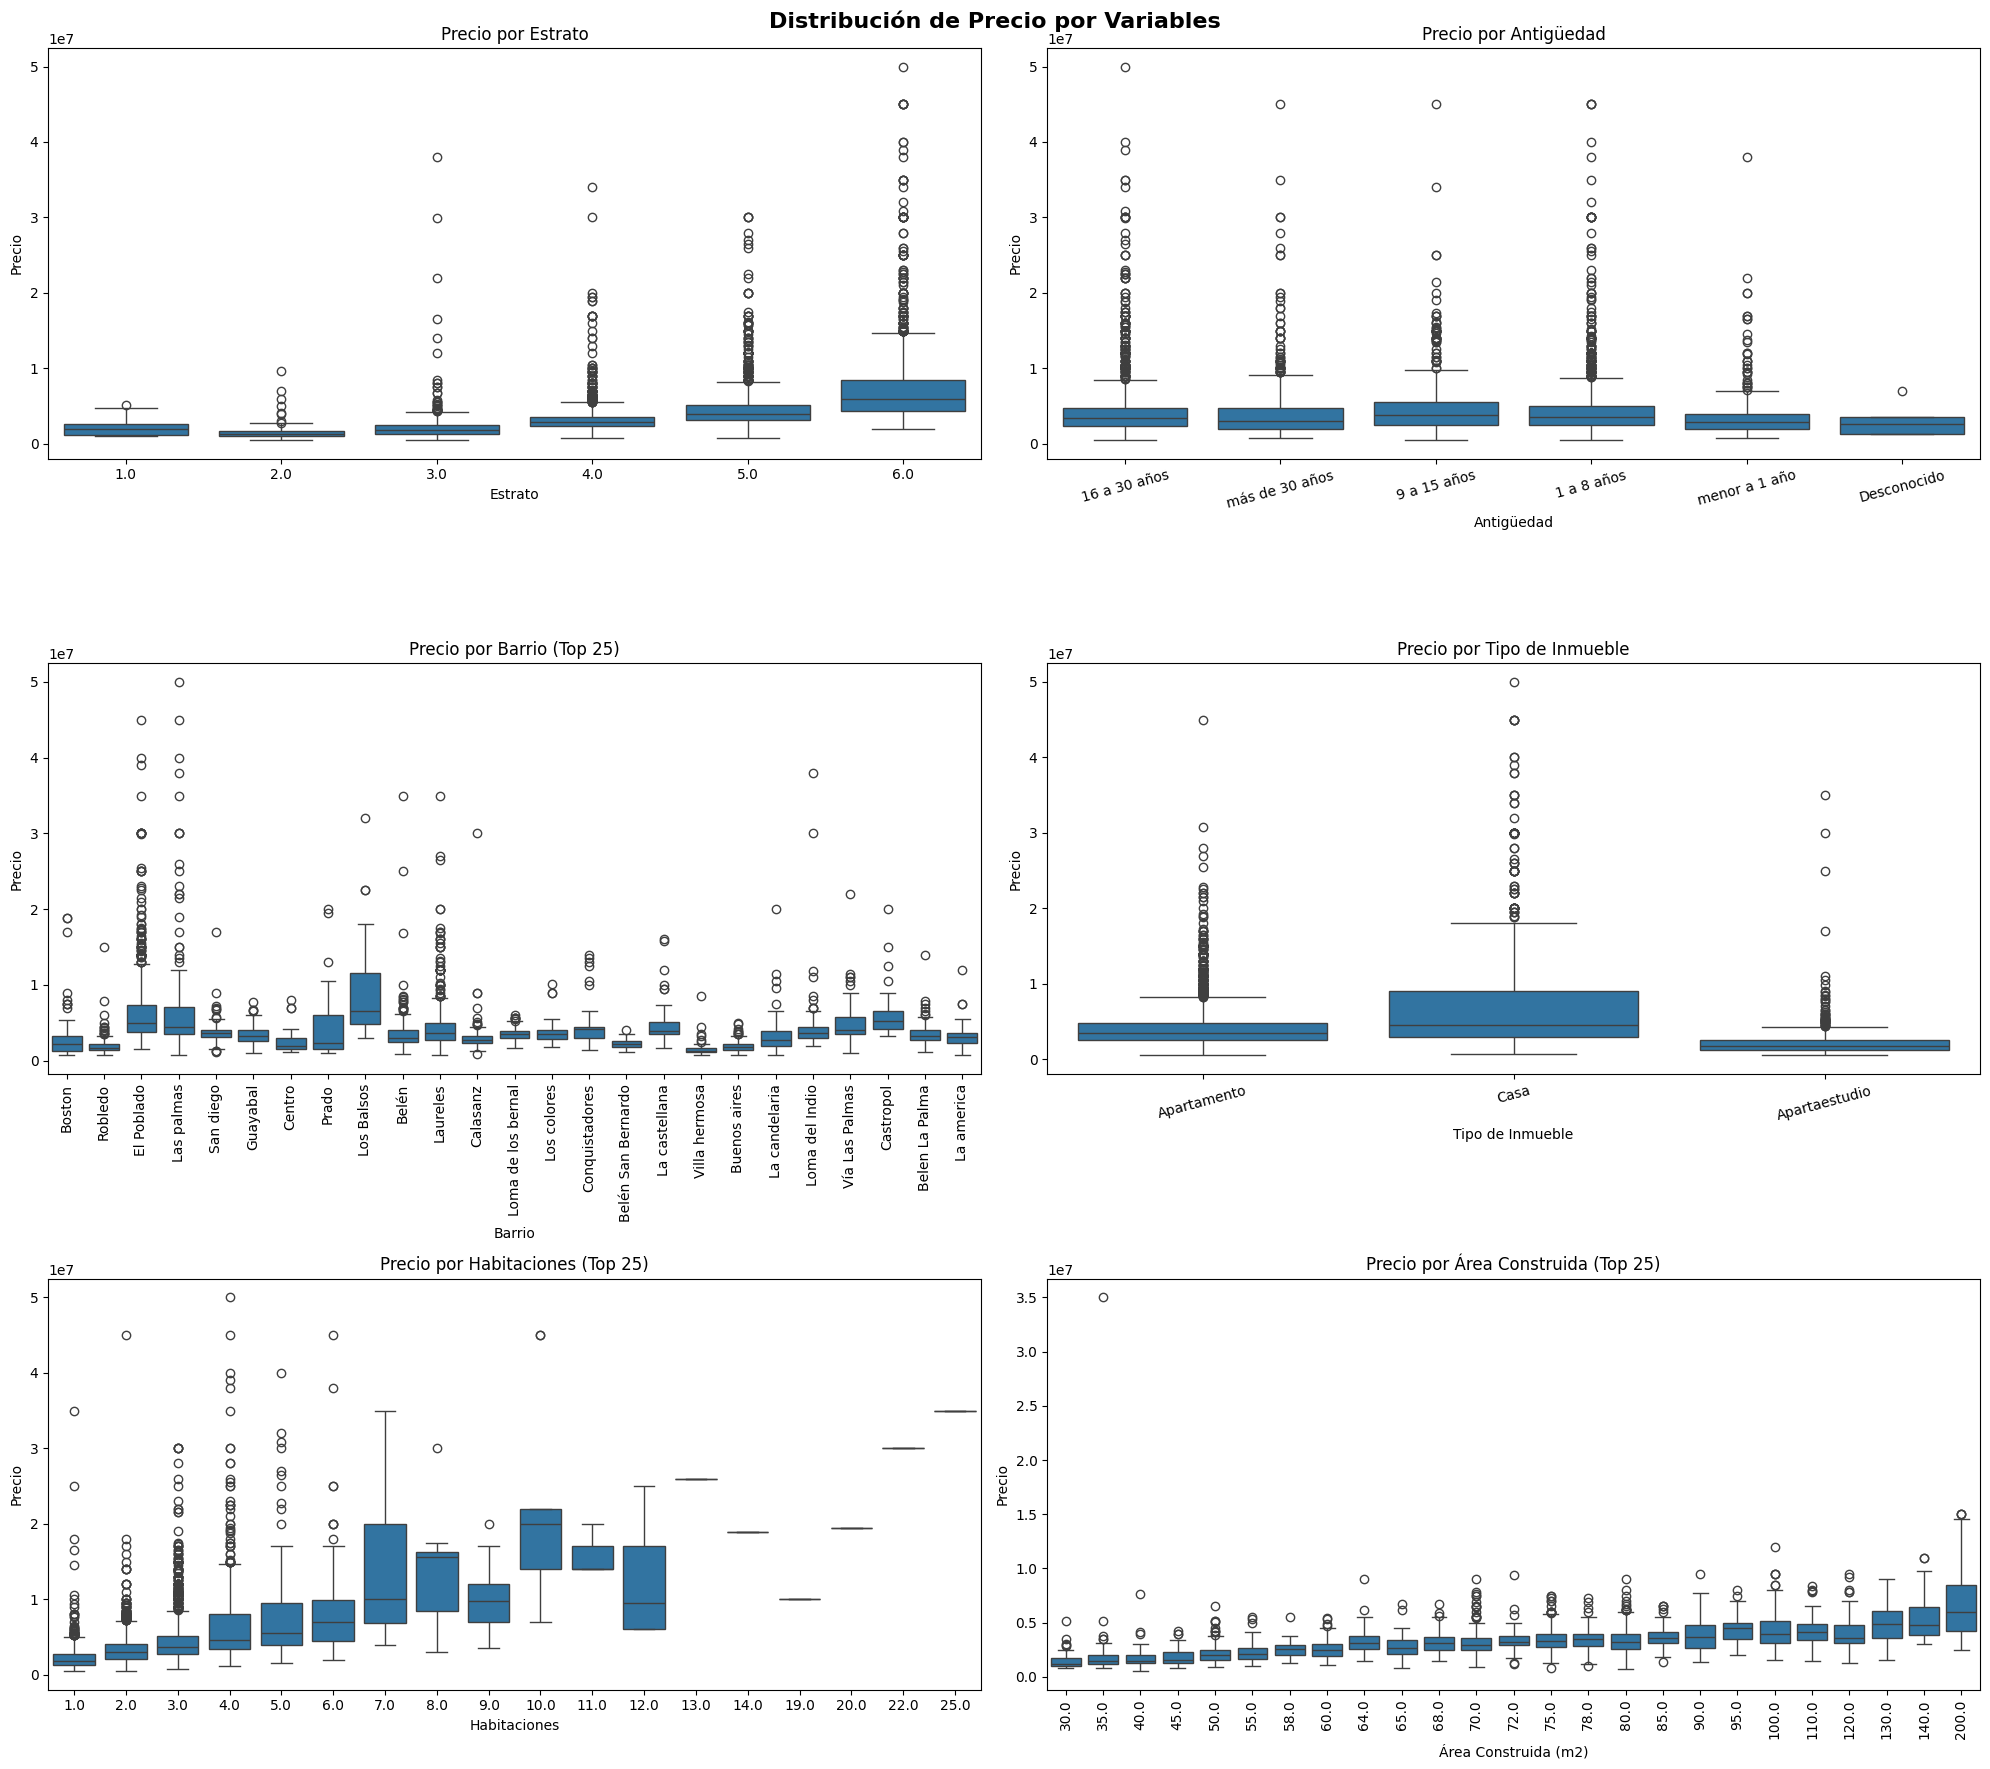

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 25 de cada variable
top_barrios = df_filtrado["Barrio"].value_counts().head(25).index
top_habitaciones = df_filtrado["Habitaciones"].value_counts().head(25).index
top_area = df_filtrado["Área Construida (m2)"].value_counts().head(25).index

# Filtros
df_barrio = df_filtrado[df_filtrado["Barrio"].isin(top_barrios)]
df_hab = df_filtrado[df_filtrado["Habitaciones"].isin(top_habitaciones)]
df_area = df_filtrado[df_filtrado["Área Construida (m2)"].isin(top_area)]

# Tablero
fig, axes = plt.subplots(3, 2, figsize=(20, 18))
fig.suptitle("Distribución de Precio por Variables", fontsize=16, fontweight="bold")

# 1. Estrato
sns.boxplot(data=df_filtrado, x="Estrato", y="Precio", ax=axes[0, 0])
axes[0, 0].set_title("Precio por Estrato")

# 2. Antigüedad
sns.boxplot(data=df_filtrado, x="Antigüedad", y="Precio", ax=axes[0, 1])
axes[0, 1].set_title("Precio por Antigüedad")
axes[0, 1].tick_params(axis="x", rotation=15)

# 3. Barrio (Top 25)
sns.boxplot(data=df_barrio, x="Barrio", y="Precio", ax=axes[1, 0])
axes[1, 0].set_title("Precio por Barrio (Top 25)")
axes[1, 0].tick_params(axis="x", rotation=90)

# 4. Tipo de Inmueble
sns.boxplot(data=df_filtrado, x="Tipo de Inmueble", y="Precio", ax=axes[1, 1])
axes[1, 1].set_title("Precio por Tipo de Inmueble")
axes[1, 1].tick_params(axis="x", rotation=15)

# 5. Habitaciones (Top 25)
sns.boxplot(data=df_hab, x="Habitaciones", y="Precio", ax=axes[2, 0])
axes[2, 0].set_title("Precio por Habitaciones (Top 25)")

# 6. Área Construida (Top 25)
sns.boxplot(data=df_area, x="Área Construida (m2)", y="Precio", ax=axes[2, 1])
axes[2, 1].set_title("Precio por Área Construida (Top 25)")
axes[2, 1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

**6. Top 20 barrios con mayor oferta de inmuebles y su precio mediano de arriendo**

In [101]:
# Cantidad e inmuebles y precio promedio por barrio
df_tree = df_filtrado.groupby("Barrio").agg(
    cantidad=("Precio", "count"),
    precio_mediano=("Precio", "median")
).sort_values("cantidad", ascending=False).head(20).reset_index()

fig = px.treemap(df_tree, 
                 path=["Barrio"],
                 values="cantidad",
                 color="precio_mediano",
                 color_continuous_scale="Viridis",
                 title="Inmuebles por Barrio - Precio Mediano (Top 20)",
                 width=1500, height=600)

fig.update_traces(texttemplate="<b>%{label}</b><br>Cantidad: %{value}<br>Precio: $%{customdata[0]:,.0f}",
                  customdata=df_tree[["precio_mediano"]].values)
fig.show()

**7. Top 10 barrios más caros vs más baratos**

In [102]:
mediana_barrio = df_filtrado.groupby("Barrio")["Precio"].median().reset_index()
mediana_barrio.columns = ["Barrio", "Precio Mediana"]

top_caros = mediana_barrio.nlargest(10, "Precio Mediana")
top_baratos = mediana_barrio.nsmallest(10, "Precio Mediana")

fig = make_subplots(rows=1, cols=2, subplot_titles=["Top 10 Barrios más Caros", "Top 10 Barrios más Baratos"])

fig.add_trace(go.Bar(x=top_caros["Barrio"], y=top_caros["Precio Mediana"],
                     text=top_caros["Precio Mediana"].apply(lambda x: f"${x:,.0f}"),
                     textposition='outside', showlegend=False), row=1, col=1)

fig.add_trace(go.Bar(x=top_baratos["Barrio"], y=top_baratos["Precio Mediana"],
                     text=top_baratos["Precio Mediana"].apply(lambda x: f"${x:,.0f}"),
                     textposition='outside', showlegend=False), row=1, col=2)

fig.update_layout(title="Top 10 Barrios más Caros vs más Baratos", height=450, width=1000)
fig.update_xaxes(tickangle=-45)
fig.show()

# **Por qué es difícil fijar un precio de arriendo justo?**

In [103]:
# Apartamentos de 3 habitaciones estrato 4 — deberían costar similar
barrios_estrato4 = ["El Poblado", "Laureles"]

df_similar = df_filtrado[
    (df_filtrado["Habitaciones"] == 3) &
    (df_filtrado["Estrato"] == 4) &
    (df_filtrado["Tipo de Inmueble"] == "Apartamento") &
    (df_filtrado["Barrio"].isin(barrios_estrato4))
]

fig = px.histogram(df_similar, x="Precio", nbins=30,
                   color="Barrio",
                   title="Precios de Apartamentos: 3 hab, Estrato 4 por Barrio",
                   width=900, height=450)
fig.update_traces(marker_line_width=1, marker_line_color="white")
fig.update_layout(bargap=0.05)
fig.show()

**Observación**

Incluso comparando inmuebles relativamente parecidos, el precio sigue variando bastante entre barrios y también dentro del mismo barrio. Esto refuerza la idea de que el canon de arriendo no puede fijarse con una sola regla simple y que se necesita un modelo que combine varias variables.

**2. Distribución de precios para `Barrios` con mas registros en el dataset**

In [104]:
top_barrios = df_filtrado["Barrio"].value_counts().head(20).index

fig = px.box(df_filtrado[df_filtrado["Barrio"].isin(top_barrios)],
             x="Barrio", y="Precio",
             title="Precio por Barrio (Top 20)",
             width=1000, height=500)
fig.update_layout(xaxis_tickangle=-45)
fig.show()

**Observación**

 la ubicación influye mucho en el canon. No es lo mismo un inmueble en un barrio que en otro, y además dentro de un mismo barrio también hay dispersión de precios. Eso indica que no basta con decir “es en Medellín” o “es en una buena zona”

**3. `Área Construida` vs precios por `Estrato`**

In [105]:
fig = px.scatter(df_filtrado[df_filtrado["Área Construida (m2)"] <= 500], 
                 x="Área Construida (m2)", y="Precio",
                 color="Estrato", opacity=0.4,
                 title="Área Construida vs Precio por Estrato",
                 width=800, height=450)
fig.show()

**Observación**

el precio no aumenta solo por el tamaño. Dos viviendas con áreas parecidas pueden tener precios distintos según su estrato. Eso evidencia que el valor depende de la combinación entre características físicas y contexto socioeconómico.

**4. ``Precio`` por ``Estrato`` + `Tipo de Inmueble` combinados** 

In [106]:
fig = px.box(df_filtrado, x="Estrato", y="Precio",
             color="Tipo de Inmueble",
             title="Precio por Estrato y Tipo de Inmueble",
             labels={"Estrato": "Estrato", "Precio": "Precio"},
             width=900, height=450)
fig.show()

**Observación**

dentro del mismo estrato el precio cambia según si es apartamento, casa o apartaestudio. Eso ayuda a demostrar que una sola variable no explica bien el precio

# **Creación archivo parquet**

In [107]:
# Creamos la carpeta "data/processed" si no existe
import os

os.makedirs("../data/processed", exist_ok=True)


In [108]:
#guardar en .parquet
df_filtrado.to_parquet("../data/processed/dataset.parquet", index=False)

In [109]:
df_filtrado.shape

(5612, 17)

In [110]:
# ============================================================================
# CELDA PARA AGREGAR AL FINAL DE TU NOTEBOOK
# ============================================================================
# Copia todo este contenido en una nueva celda al final de tu notebook
# y ejecútala después de completar el análisis

# INSTRUCCIONES:
# 1. Asegúrate de que estas variables existen en tu notebook:
#    - df (dataset original)
#    - X_train, X_test (después de limpieza e imputación)
#    - y_train, y_test
# 2. Ejecuta esta celda
# 3. Se generará un archivo HTML en la misma carpeta del notebook
# 4. Ábrelo en tu navegador

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import base64
from io import BytesIO
from datetime import datetime

print("="*70)
print("GENERANDO REPORTE HTML PROFESIONAL")
print("="*70)

# Función auxiliar para convertir gráficos a base64
def fig_to_base64(fig):
    buffer = BytesIO()
    fig.savefig(buffer, format='png', dpi=150, bbox_inches='tight')
    buffer.seek(0)
    image_base64 = base64.b64encode(buffer.read()).decode()
    plt.close(fig)
    return f"data:image/png;base64,{image_base64}"

# Función para convertir plotly a HTML
def plotly_to_html(fig):
    return fig.to_html(include_plotlyjs='cdn', div_id=None, config={'displayModeBar': False})

# ============================================================================
# CALCULAR ESTADÍSTICAS
# ============================================================================
print("\n📊 Calculando estadísticas...")

df_completo = pd.concat([X_train, X_test], axis=0)
y_completo = pd.concat([y_train, y_test], axis=0)

stats = {
    'registros_originales': len(df),
    'registros_finales': len(df_completo),
    'registros_eliminados': len(df) - len(df_completo),
    'pct_eliminados': ((len(df) - len(df_completo)) / len(df) * 100),
    'train_size': len(X_train),
    'test_size': len(X_test),
    'n_features': X_train.shape[1],
    'precio_min': y_completo.min(),
    'precio_max': y_completo.max(),
    'precio_median': y_completo.median(),
    'precio_mean': y_completo.mean(),
}

# ============================================================================
# GENERAR GRÁFICOS
# ============================================================================
print("📈 Generando gráficos...")

# Gráfico 1: Distribución de Precio
fig1, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_train, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(y_train.median(), color='red', linestyle='--', linewidth=2, 
                label=f'Mediana: ${y_train.median():,.0f}')
axes[0].set_xlabel('Precio (COP)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frecuencia', fontsize=12, fontweight='bold')
axes[0].set_title('Distribución de Precio de Arriendo', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].boxplot(y_train, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Precio (COP)', fontsize=12, fontweight='bold')
axes[1].set_title('Boxplot de Precio', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
grafico_precio = fig_to_base64(fig1)

# Gráfico 2: Variables Principales
cols_principales = ['Área Construida (m2)', 'Habitaciones', 'Baños', 'Estrato']
cols_disponibles = [c for c in cols_principales if c in X_train.columns]

n_cols = len(cols_disponibles)
fig2, axes = plt.subplots(1, n_cols, figsize=(5*n_cols, 4))
if n_cols == 1:
    axes = [axes]

for idx, col in enumerate(cols_disponibles):
    axes[idx].hist(X_train[col], bins=30, alpha=0.7, color='coral', edgecolor='black')
    axes[idx].axvline(X_train[col].median(), color='red', linestyle='--', 
                     linewidth=2, label=f'Mediana: {X_train[col].median():.1f}')
    axes[idx].set_xlabel(col, fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Frecuencia', fontsize=11)
    axes[idx].set_title(f'Distribución de {col}', fontsize=12, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
grafico_variables = fig_to_base64(fig2)

# Gráfico 3: Tipo de Inmueble (Plotly)
if 'Tipo de Inmueble' in X_train.columns:
    tipo_counts = X_train['Tipo de Inmueble'].value_counts()
    
    fig3 = go.Figure(data=[
        go.Pie(labels=tipo_counts.index, 
               values=tipo_counts.values,
               hole=0.4,
               marker=dict(colors=['#3498db', '#e74c3c', '#2ecc71']),
               textinfo='label+percent',
               textfont=dict(size=14))
    ])
    
    fig3.update_layout(
        title='Distribución por Tipo de Inmueble',
        title_font=dict(size=16, family='Arial Black'),
        height=400
    )
    
    grafico_tipo = plotly_to_html(fig3)
else:
    grafico_tipo = "<p>Tipo de Inmueble no disponible</p>"

# Gráfico 4: Top 10 Barrios
if 'Barrio_group' in X_train.columns:
    top_barrios = X_train['Barrio_group'].value_counts().head(10)
    
    fig4 = go.Figure(data=[
        go.Bar(x=top_barrios.values, 
               y=top_barrios.index,
               orientation='h',
               marker=dict(color='#9b59b6'),
               text=top_barrios.values,
               textposition='outside')
    ])
    
    fig4.update_layout(
        title='Top 10 Barrios con Más Oferta',
        title_font=dict(size=16, family='Arial Black'),
        xaxis_title='Número de Inmuebles',
        yaxis_title='Barrio',
        height=400,
        yaxis={'categoryorder': 'total ascending'}
    )
    
    grafico_barrios = plotly_to_html(fig4)
else:
    grafico_barrios = "<p>Barrio no disponible</p>"

# Gráfico 5: Precio por Tipo
if 'Tipo de Inmueble' in X_train.columns:
    df_precio_tipo = pd.DataFrame({
        'Tipo de Inmueble': X_train['Tipo de Inmueble'],
        'Precio': y_train
    })
    
    fig5 = go.Figure()
    
    for tipo in df_precio_tipo['Tipo de Inmueble'].unique():
        datos_tipo = df_precio_tipo[df_precio_tipo['Tipo de Inmueble'] == tipo]['Precio']
        fig5.add_trace(go.Box(y=datos_tipo, name=tipo, boxmean='sd'))
    
    fig5.update_layout(
        title='Distribución de Precio por Tipo de Inmueble',
        title_font=dict(size=16, family='Arial Black'),
        yaxis_title='Precio (COP)',
        height=450
    )
    
    grafico_precio_tipo = plotly_to_html(fig5)
else:
    grafico_precio_tipo = "<p>Tipo de Inmueble no disponible</p>"

# ============================================================================
# GENERAR HTML
# ============================================================================
print("📝 Generando HTML...")

html_content = f"""
<!DOCTYPE html>
<html lang="es">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Reporte - Análisis de Viviendas en Arriendo</title>
    <script src="https://cdn.plot.ly/plotly-latest.min.js"></script>
    <style>
        * {{ margin: 0; padding: 0; box-sizing: border-box; }}
        body {{ 
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
            line-height: 1.6;
            color: #333;
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            padding: 20px;
        }}
        .container {{ 
            max-width: 1400px;
            margin: 0 auto;
            background: white;
            border-radius: 15px;
            box-shadow: 0 10px 40px rgba(0,0,0,0.3);
            overflow: hidden;
        }}
        header {{ 
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
            padding: 40px;
            text-align: center;
        }}
        header h1 {{ font-size: 2.5em; margin-bottom: 10px; font-weight: 700; }}
        header p {{ font-size: 1.1em; opacity: 0.9; }}
        .metadata {{ 
            background: #f8f9fa;
            padding: 20px 40px;
            border-bottom: 3px solid #667eea;
            display: flex;
            justify-content: space-between;
            flex-wrap: wrap;
        }}
        .metadata-item {{ margin: 10px 0; }}
        .metadata-item strong {{ color: #667eea; }}
        .section {{ padding: 40px; }}
        .section-title {{ 
            font-size: 2em;
            color: #667eea;
            margin-bottom: 20px;
            padding-bottom: 10px;
            border-bottom: 3px solid #667eea;
            font-weight: 700;
        }}
        .stats-grid {{ 
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(250px, 1fr));
            gap: 20px;
            margin: 30px 0;
        }}
        .stat-card {{ 
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
            padding: 25px;
            border-radius: 10px;
            text-align: center;
            box-shadow: 0 4px 15px rgba(102, 126, 234, 0.3);
            transition: transform 0.3s ease;
        }}
        .stat-card:hover {{ transform: translateY(-5px); }}
        .stat-card h3 {{ font-size: 0.9em; opacity: 0.9; margin-bottom: 10px; }}
        .stat-card .value {{ font-size: 2.2em; font-weight: 700; margin-bottom: 5px; }}
        .stat-card .subtitle {{ font-size: 0.85em; opacity: 0.8; }}
        .graph-container {{ 
            margin: 30px 0;
            padding: 20px;
            background: #f8f9fa;
            border-radius: 10px;
            box-shadow: 0 2px 10px rgba(0,0,0,0.1);
        }}
        .graph-container img {{ width: 100%; height: auto; border-radius: 8px; }}
        .success {{ 
            background: #d4edda;
            border-left: 4px solid #28a745;
            padding: 15px 20px;
            margin: 20px 0;
            border-radius: 5px;
        }}
        .info-box {{ 
            background: #e3f2fd;
            border-left: 4px solid #2196F3;
            padding: 20px;
            margin: 20px 0;
            border-radius: 5px;
        }}
        .info-box h4 {{ color: #1976D2; margin-bottom: 10px; font-size: 1.2em; }}
        .info-box ul {{ margin-left: 20px; }}
        .info-box li {{ margin: 8px 0; }}
        table {{ width: 100%; border-collapse: collapse; margin: 20px 0; }}
        table th {{ background: #667eea; color: white; padding: 15px; text-align: left; }}
        table td {{ padding: 12px 15px; border-bottom: 1px solid #ddd; }}
        table tr:nth-child(even) {{ background: #f8f9fa; }}
        footer {{ background: #2c3e50; color: white; text-align: center; padding: 20px; }}
        .badge {{ 
            display: inline-block;
            padding: 5px 15px;
            background: #28a745;
            color: white;
            border-radius: 20px;
            font-size: 0.9em;
            font-weight: 600;
        }}
    </style>
</head>
<body>
    <div class="container">
        <header>
            <h1>📊 Reporte de Análisis Exploratorio</h1>
            <p>Viviendas en Arriendo - Medellín, Colombia</p>
        </header>
        
        <div class="metadata">
            <div class="metadata-item">
                <strong>Fecha:</strong> {datetime.now().strftime('%d/%m/%Y %H:%M')}
            </div>
            <div class="metadata-item">
                <strong>Dataset:</strong> Finca Raíz - Arriendos
            </div>
        </div>
        
        <div class="section">
            <h2 class="section-title">📋 Resumen Ejecutivo</h2>
            
            <div class="success">
                <strong>✅ Análisis completado exitosamente</strong><br>
                Dataset procesado sin data leakage y listo para modelado.
            </div>
            
            <div class="stats-grid">
                <div class="stat-card">
                    <h3>Registros Originales</h3>
                    <div class="value">{stats['registros_originales']:,}</div>
                </div>
                <div class="stat-card">
                    <h3>Registros Finales</h3>
                    <div class="value">{stats['registros_finales']:,}</div>
                </div>
                <div class="stat-card">
                    <h3>Eliminados</h3>
                    <div class="value">{stats['registros_eliminados']:,}</div>
                    <div class="subtitle">{stats['pct_eliminados']:.1f}%</div>
                </div>
                <div class="stat-card">
                    <h3>Features</h3>
                    <div class="value">{stats['n_features']}</div>
                </div>
            </div>
            
            <div class="info-box">
                <h4>🎯 Proceso Aplicado</h4>
                <ul>
                    <li>Duplicados eliminados priorizando completitud</li>
                    <li>Consistencias validadas (áreas, pisos)</li>
                    <li>Outliers extremos removidos</li>
                    <li>Imputación KNN sin data leakage</li>
                    <li>Split 80/20 estratificado</li>
                </ul>
            </div>
        </div>
        
        <div class="section">
            <h2 class="section-title">💰 Análisis de Precio</h2>
            
            <div class="stats-grid">
                <div class="stat-card">
                    <h3>Mínimo</h3>
                    <div class="value">${stats['precio_min']:,.0f}</div>
                </div>
                <div class="stat-card">
                    <h3>Mediana</h3>
                    <div class="value">${stats['precio_median']:,.0f}</div>
                </div>
                <div class="stat-card">
                    <h3>Promedio</h3>
                    <div class="value">${stats['precio_mean']:,.0f}</div>
                </div>
                <div class="stat-card">
                    <h3>Máximo</h3>
                    <div class="value">${stats['precio_max']:,.0f}</div>
                </div>
            </div>
            
            <div class="graph-container">
                <img src="{grafico_precio}" alt="Distribución de Precio">
            </div>
        </div>
        
        <div class="section">
            <h2 class="section-title">🏠 Características</h2>
            
            <div class="graph-container">
                <img src="{grafico_variables}" alt="Variables Principales">
            </div>
            
            <div class="graph-container">
                {grafico_tipo}
            </div>
            
            <div class="graph-container">
                {grafico_precio_tipo}
            </div>
        </div>
        
        <div class="section">
            <h2 class="section-title">📍 Geografía</h2>
            
            <div class="graph-container">
                {grafico_barrios}
            </div>
        </div>
        
        <div class="section">
            <h2 class="section-title">🔧 Detalles Técnicos</h2>
            
            <table>
                <tr>
                    <th>Aspecto</th>
                    <th>Valor</th>
                </tr>
                <tr>
                    <td><strong>Train Set</strong></td>
                    <td>{stats['train_size']:,} ({stats['train_size']/(stats['train_size']+stats['test_size'])*100:.1f}%)</td>
                </tr>
                <tr>
                    <td><strong>Test Set</strong></td>
                    <td>{stats['test_size']:,} ({stats['test_size']/(stats['train_size']+stats['test_size'])*100:.1f}%)</td>
                </tr>
                <tr>
                    <td><strong>Método</strong></td>
                    <td>KNN Imputer (k=5)</td>
                </tr>
                <tr>
                    <td><strong>Data Leakage</strong></td>
                    <td><span class="badge">✅ Evitado</span></td>
                </tr>
            </table>
        </div>
        
        <footer>
            <p>Reporte generado desde Jupyter Notebook</p>
            <p>© {datetime.now().year} - Análisis de Datos</p>
        </footer>
    </div>
</body>
</html>
"""

# Guardar HTML
output_file = 'reporte_analisis_viviendas.html'
with open(output_file, 'w', encoding='utf-8') as f:
    f.write(html_content)

print(f"\n{'='*70}")
print(f"✅ REPORTE HTML GENERADO EXITOSAMENTE")
print(f"{'='*70}")
print(f"\n📂 Archivo: {output_file}")
print(f"📊 Tamaño: {len(html_content) / 1024:.1f} KB")
print(f"\n💡 Abre el archivo en tu navegador para visualizar el reporte")
print(f"\n{'='*70}")

GENERANDO REPORTE HTML PROFESIONAL

📊 Calculando estadísticas...
📈 Generando gráficos...
📝 Generando HTML...

✅ REPORTE HTML GENERADO EXITOSAMENTE

📂 Archivo: reporte_analisis_viviendas.html
📊 Tamaño: 241.0 KB

💡 Abre el archivo en tu navegador para visualizar el reporte

